### **Random Forest**

In [28]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])

X = df.drop("quality", axis=1)
y = df["quality"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SABINA COMMENT: Why are you using a scaler here?
# umm when i thought about using scaler i thought it is important for models that depend on distances or optimization , i know that it is not 
# required but i think there is no harm in adding it if i am not wrong 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)


acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", round(acc, 4))
print("Weighted F1:", round(f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


joblib.dump(model, "best_wine_model.pkl")
joblib.dump(scaler, "wine_scaler.pkl")
joblib.dump(X.columns.tolist(), "wine_feature_names.pkl")

print("\nModel saved successfully.")

Accuracy: 0.6931
Weighted F1: 0.6812

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.62      0.12      0.20        43
           5       0.75      0.72      0.73       428
           6       0.66      0.79      0.72       567
           7       0.67      0.58      0.62       216
           8       1.00      0.36      0.53        39
           9       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.53      0.37      0.40      1300
weighted avg       0.70      0.69      0.68      1300


Confusion Matrix:
[[  0   0   3   2   1   0   0]
 [  0   5  20  17   1   0   0]
 [  0   1 308 116   3   0   0]
 [  0   2  75 449  41   0   0]
 [  0   0   5  86 125   0   0]
 [  0   0   1  10  14  14   0]
 [  0   0   0   0   1   0   0]]

Model saved successfully.


SABINA COMMENT: Any thoughts on classes 3, 4, 8, and 9? Can you reliably predict them? 

 umm yes ,these result suggests that the dataset is imbalanced, and the model is biased toward the most frequent classes. To improve prediction for classes 3, 4, 8, and 9, we would need either more data for these classes, class balancing techniques, or a different modeling strategy.

### feature

                 Feature  Importance
10               alcohol    0.122918
1       volatile acidity    0.101864
7                density    0.101107
6   total sulfur dioxide    0.090780
9              sulphates    0.086475
4              chlorides    0.085108
3         residual sugar    0.084621
5    free sulfur dioxide    0.083806
8                     pH    0.082898
2            citric acid    0.079758
0          fixed acidity    0.076506
11             wine_type    0.004161


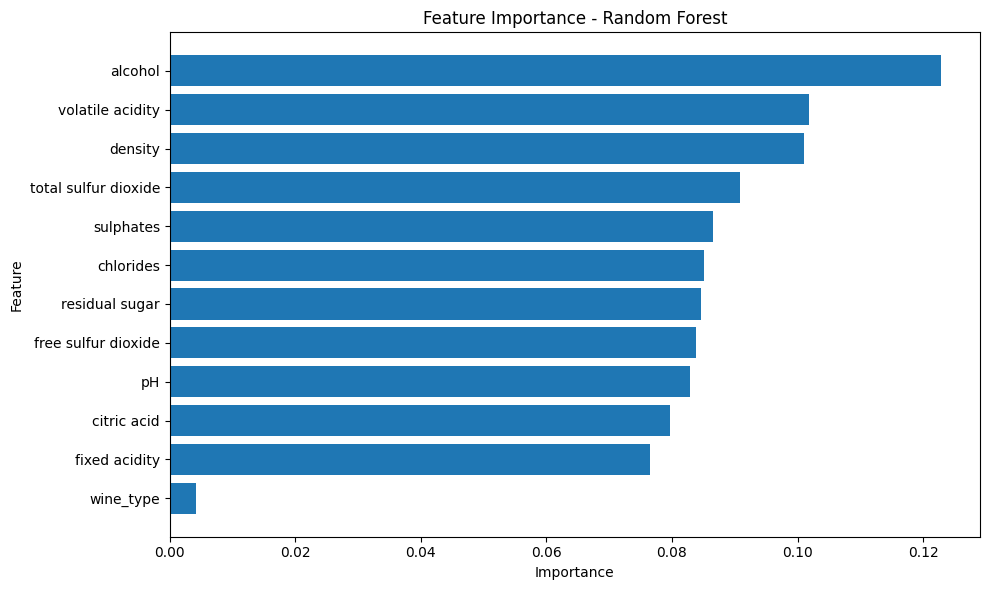

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### **confusion matrix plot**

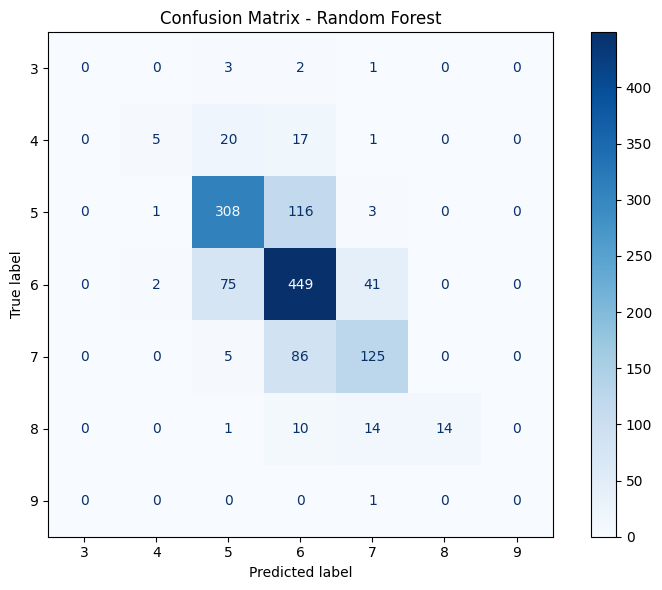

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

### results summary table

In [31]:
summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1-score"],
    "Value": [acc, f1]
})

print(summary_df)

              Metric     Value
0           Accuracy  0.693077
1  Weighted F1-score  0.681187


SABINA COMMENT: Any reason we're only looking at Random Forest? What about other models?

Also, what metrics should we be using to figure out what model performs the best?

The best model should be selected using multiple metrics such as accuracy, weighted F1-score, and confusion matrix-

here is the another moadel also decison tree 

### ***Decision Tree***

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])  # red/white -> 0/1


X = df.drop("quality", axis=1)
y = df["quality"]


stratify_col = df["quality"].astype(str) + "_" + df["wine_type"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        random_state=42,
        objective="multi:softmax",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss"
    )


results = []

for name, model in models.items():
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)

    if name == "XGBoost":
        model.fit(X_train, y_train_encoded)
        y_pred_encoded = model.predict(X_test)
        y_pred = label_encoder.inverse_transform(y_pred_encoded.astype(int))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(acc, 4))
    print("Weighted F1-score:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted F1": f1
    })

results_df = pd.DataFrame(results).sort_values(by="Weighted F1", ascending=False)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model based on weighted F1-score: {best_model_name}")


MODEL: Decision Tree
Accuracy: 0.5931
Weighted F1-score: 0.5911

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.23      0.18      0.20        44
           5       0.61      0.62      0.62       427
           6       0.63      0.63      0.63       568
           7       0.57      0.56      0.57       216
           8       0.40      0.47      0.43        38
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.35      0.35      0.35      1300
weighted avg       0.59      0.59      0.59      1300

Confusion Matrix:
[[  0   1   2   3   0   0   0]
 [  1   8  21  10   3   1   0]
 [  0  17 266 124  16   3   1]
 [  1   6 125 358  64  14   0]
 [  0   2  17  68 121   8   0]
 [  0   1   5   6   8  18   0]
 [  0   0   0   0   0   1   0]]

MODEL: Random Forest
Accuracy: 0.6746
Weighted F1-score: 0.6629

Classificati

### ***Logistic Regression***

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)


wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])

X = df.drop("quality", axis=1)
y = df["quality"]


stratify_col = df["quality"].astype(str) + "_" + df["wine_type"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1-score:", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5476923076923077
Weighted F1-score: 0.5165765011215214

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.80      0.09      0.16        44
           5       0.60      0.58      0.59       427
           6       0.52      0.72      0.61       568
           7       0.53      0.22      0.31       216
           8       0.00      0.00      0.00        38
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1300
   macro avg       0.35      0.23      0.24      1300
weighted avg       0.54      0.55      0.52      1300

Confusion Matrix:
[[  0   0   1   4   0   1   0]
 [  0   4  23  17   0   0   0]
 [  0   1 249 173   4   0   0]
 [  0   0 127 411  30   0   0]
 [  0   0  13 155  48   0   0]
 [  0   0   3  27   8   0   0]
 [  0   0   0   0   1   0   0]]


In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False


red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)


wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])  # red=0, white=1


X = df.drop("quality", axis=1)
y = df["quality"]


stratify_col = df["quality"].astype(str) + "_" + df["wine_type"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42
    )

results = []

best_model = None
best_model_name = None
best_f1 = -1

for name, model in models.items():
    print("\n" + "=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    if name == "XGBoost":
        model.fit(X_train, y_train_encoded)
        y_pred_encoded = model.predict(X_test)
        y_pred = label_encoder.inverse_transform(y_pred_encoded.astype(int))

    elif name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(acc, 4))
    print("Weighted F1:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted F1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results).sort_values(by="Weighted F1", ascending=False)

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(results_df)

print(f"\nBest model based on Weighted F1-score: {best_model_name}")



MODEL: Decision Tree
Accuracy: 0.5931
Weighted F1: 0.5911

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.23      0.18      0.20        44
           5       0.61      0.62      0.62       427
           6       0.63      0.63      0.63       568
           7       0.57      0.56      0.57       216
           8       0.40      0.47      0.43        38
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.35      0.35      0.35      1300
weighted avg       0.59      0.59      0.59      1300

Confusion Matrix:
[[  0   1   2   3   0   0   0]
 [  1   8  21  10   3   1   0]
 [  0  17 266 124  16   3   1]
 [  1   6 125 358  64  14   0]
 [  0   2  17  68 121   8   0]
 [  0   1   5   6   8  18   0]
 [  0   0   0   0   0   1   0]]

MODEL: Random Forest
Accuracy: 0.6746
Weighted F1: 0.6629

Classification Report:
 

## At the end

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)


wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])  # red=0, white=1

X = df.drop("quality", axis=1)
y = df["quality"]

stratify_col = df["quality"].astype(str) + "_" + df["wine_type"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


dt_model = DecisionTreeClassifier(random_state=42)
lr_model = LogisticRegression(max_iter=2000, random_state=42)
rf_model = RandomForestClassifier(random_state=42)


dt_model.fit(X_train, y_train)
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)


acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average="weighted")

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("\nLogistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Decision Tree Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.23      0.18      0.20        44
           5       0.61      0.62      0.62       427
           6       0.63      0.63      0.63       568
           7       0.57      0.56      0.57       216
           8       0.40      0.47      0.43        38
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.35      0.35      0.35      1300
weighted avg       0.59      0.59      0.59      1300


Logistic Regression Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.80      0.09      0.16        44
           5       0.60      0.58      0.59       427
           6       0.52      0.72      0.61       568
           7       0.53      0.22      0.31       216

## Feature 


Decision Tree Feature Importances:
                 Feature  Decision Tree Importance
10               alcohol                  0.144968
1       volatile acidity                  0.111598
5    free sulfur dioxide                  0.097283
9              sulphates                  0.093329
6   total sulfur dioxide                  0.086015
3         residual sugar                  0.084688
7                density                  0.079903
4              chlorides                  0.076637
2            citric acid                  0.075570
0          fixed acidity                  0.074661
8                     pH                  0.072979
11             wine_type                  0.002369


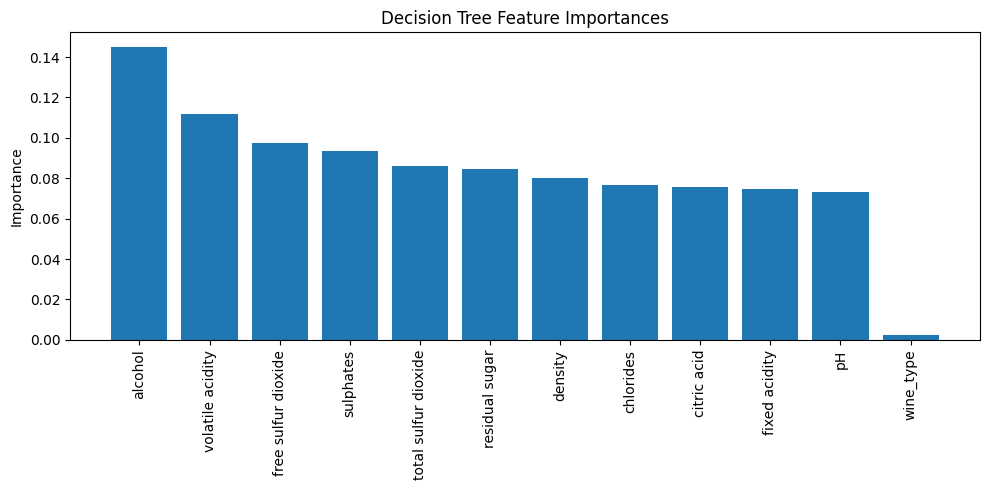


Random Forest Feature Importances:
                 Feature  Random Forest Importance
10               alcohol                  0.122632
7                density                  0.099547
1       volatile acidity                  0.098685
6   total sulfur dioxide                  0.090926
9              sulphates                  0.088339
5    free sulfur dioxide                  0.086435
4              chlorides                  0.085106
3         residual sugar                  0.085020
8                     pH                  0.083648
2            citric acid                  0.080079
0          fixed acidity                  0.075658
11             wine_type                  0.003922


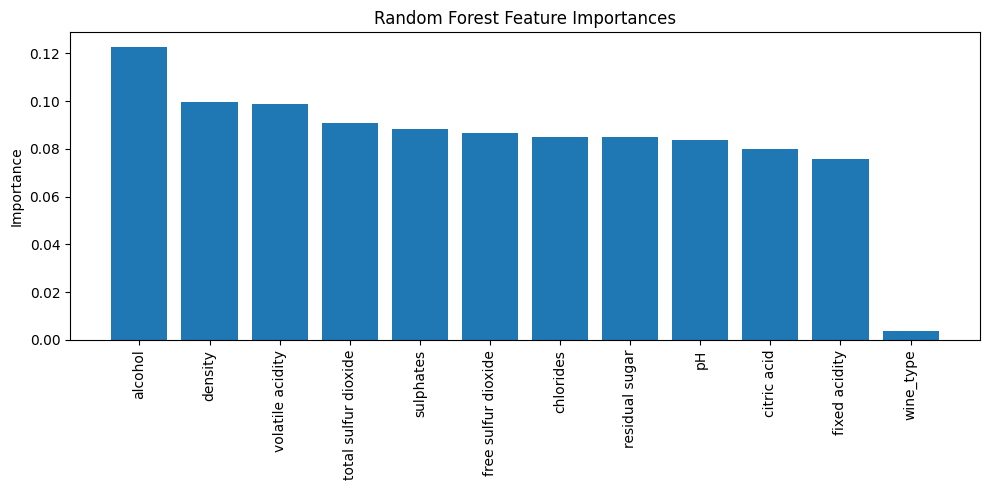


Logistic Regression Feature Summary:
                 Feature  Logistic Regression Mean Abs Coef
11             wine_type                           0.642588
1       volatile acidity                           0.581796
7                density                           0.564471
3         residual sugar                           0.556997
10               alcohol                           0.529588
0          fixed acidity                           0.409579
4              chlorides                           0.321044
8                     pH                           0.292102
5    free sulfur dioxide                           0.287079
9              sulphates                           0.264196
6   total sulfur dioxide                           0.155794
2            citric acid                           0.047569


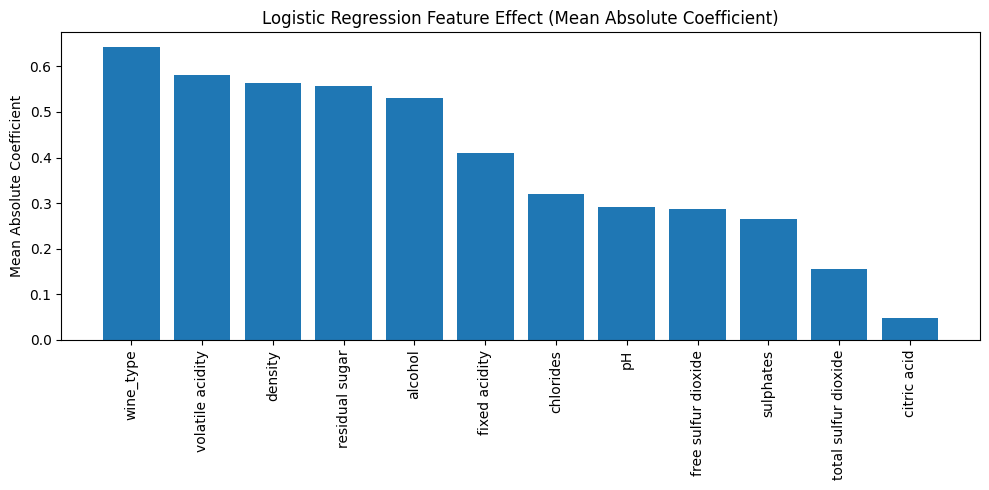

In [36]:
# Decision Tree feature importance
dt_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Decision Tree Importance": dt_model.feature_importances_
}).sort_values(by="Decision Tree Importance", ascending=False)

print("\nDecision Tree Feature Importances:")
print(dt_importance_df)

plt.figure(figsize=(10, 5))
plt.bar(dt_importance_df["Feature"], dt_importance_df["Decision Tree Importance"])
plt.xticks(rotation=90)
plt.title("Decision Tree Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Random Forest feature importance
rf_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest Importance": rf_model.feature_importances_
}).sort_values(by="Random Forest Importance", ascending=False)

print("\nRandom Forest Feature Importances:")
print(rf_importance_df)

plt.figure(figsize=(10, 5))
plt.bar(rf_importance_df["Feature"], rf_importance_df["Random Forest Importance"])
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Logistic Regression feature summary
lr_coef_mean = np.mean(np.abs(lr_model.coef_), axis=0)

lr_features_df = pd.DataFrame({
    "Feature": X.columns,
    "Logistic Regression Mean Abs Coef": lr_coef_mean
}).sort_values(by="Logistic Regression Mean Abs Coef", ascending=False)

print("\nLogistic Regression Feature Summary:")
print(lr_features_df)

plt.figure(figsize=(10, 5))
plt.bar(lr_features_df["Feature"], lr_features_df["Logistic Regression Mean Abs Coef"])
plt.xticks(rotation=90)
plt.title("Logistic Regression Feature Effect (Mean Absolute Coefficient)")
plt.ylabel("Mean Absolute Coefficient")
plt.tight_layout()
plt.show()


### ** confusion matrix plot**

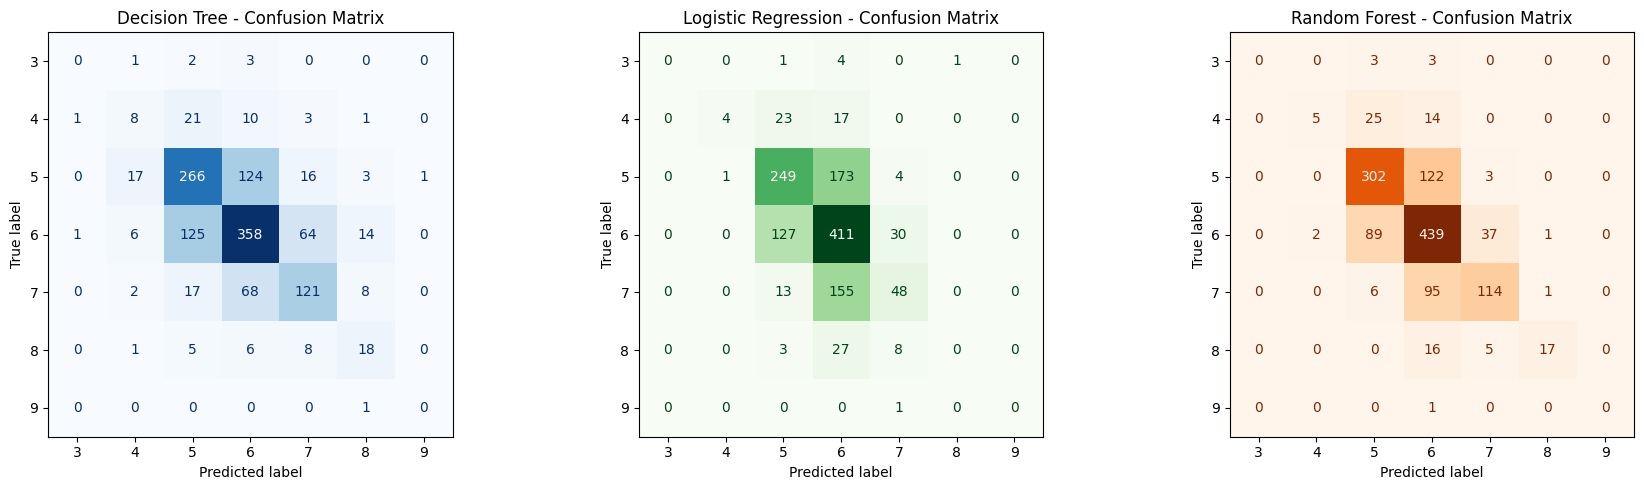

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)
disp_dt.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Decision Tree - Confusion Matrix")

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Logistic Regression - Confusion Matrix")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(ax=axes[2], cmap="Oranges", colorbar=False)
axes[2].set_title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()


### **summary table**

In [38]:
summary_df = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression", "Random Forest"],
    "Accuracy": [acc_dt, acc_lr, acc_rf],
    "Weighted F1": [f1_dt, f1_lr, f1_rf]
}).sort_values(by="Weighted F1", ascending=False)

print("\nSummary Table:")
print(summary_df)


Summary Table:
                 Model  Accuracy  Weighted F1
2        Random Forest  0.674615     0.662890
0        Decision Tree  0.593077     0.591104
1  Logistic Regression  0.547692     0.516577


In [39]:
feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Decision Tree Importance": dt_model.feature_importances_,
    "Random Forest Importance": rf_model.feature_importances_,
    "Logistic Regression Mean Abs Coef": lr_coef_mean
})

feature_summary = feature_summary.sort_values(
    by="Random Forest Importance",
    ascending=False
)

print("\nCombined Feature Summary Table:")
print(feature_summary)


Combined Feature Summary Table:
                 Feature  Decision Tree Importance  Random Forest Importance  \
10               alcohol                  0.144968                  0.122632   
7                density                  0.079903                  0.099547   
1       volatile acidity                  0.111598                  0.098685   
6   total sulfur dioxide                  0.086015                  0.090926   
9              sulphates                  0.093329                  0.088339   
5    free sulfur dioxide                  0.097283                  0.086435   
4              chlorides                  0.076637                  0.085106   
3         residual sugar                  0.084688                  0.085020   
8                     pH                  0.072979                  0.083648   
2            citric acid                  0.075570                  0.080079   
0          fixed acidity                  0.074661                  0.075658   
11     